# CLIP-Based Food Image Classification: Zero-Shot and Few-Shot Approaches

This notebook explores multimodal food image classification using OpenAI CLIP (ViT-B/16).
We evaluate two learning paradigms:
- **Zero-Shot**: classification with no task-specific training
- **Few-Shot**: lightweight linear probing using a small labeled support set (k = 5, 10)


## Section 1 — Dependency Installation

In [1]:
# Install core deep learning and vision libraries
!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets pillow accelerate
!pip install -q scikit-learn matplotlib seaborn tqdm pandas numpy
!pip install -q pycocotools gdown

# Install the CLIP package from OpenAI
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00


## Section 2 — Imports and Global Configuration

In [2]:
import os
import json
import pickle
import random
import zipfile
import subprocess
import warnings
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import clip
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    precision_score
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')


# ── Reproducibility ──────────────────────────────────────────────────────────
def fix_random_state(seed: int = 42) -> None:
    """Pin all sources of randomness for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
fix_random_state(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Runtime device: {DEVICE}")

Runtime device: cuda


## Section 3 — Load CLIP Model (ViT-B/16)

In [3]:
BACKBONE = "ViT-B/16"

print(f"Loading CLIP backbone: {BACKBONE} …")
clip_encoder, image_preprocessor = clip.load(BACKBONE, device=DEVICE)
clip_encoder.eval()

total_params = sum(p.numel() for p in clip_encoder.parameters()) / 1e6
print(f"  ✓ Loaded  |  Parameters: {total_params:.2f}M")
print(f"  Image preprocessing pipeline:\n{image_preprocessor}")

Loading CLIP backbone: ViT-B/16 …


100%|███████████████████████████████████████| 335M/335M [00:03<00:00, 91.2MiB/s]


  ✓ Loaded  |  Parameters: 149.62M
  Image preprocessing pipeline:
Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x7a9d9ec3aca0>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


## Section 4 — Dataset Download (UPMC Food-101, 10-class subset)

In [4]:
GDRIVE_FILE_ID = "19SsVYSMYGkciQyqfArAYZkvsbmiS1N8A"
ARCHIVE_PATH   = "/content/dataset.zip"
UNZIP_ROOT     = "/content/dataset"

# Download via gdown
subprocess.run(["gdown", "--id", GDRIVE_FILE_ID, "-O", ARCHIVE_PATH], check=True)

# Unpack
os.makedirs(UNZIP_ROOT, exist_ok=True)
with zipfile.ZipFile(ARCHIVE_PATH, "r") as zf:
    zf.extractall(UNZIP_ROOT)

DATA_ROOT  = os.path.join(UNZIP_ROOT, "data")
TRAIN_DIR  = os.path.join(DATA_ROOT, "train")
TEST_DIR   = os.path.join(DATA_ROOT, "test")
TRAIN_CSV  = os.path.join(DATA_ROOT, "texts", "train_titles.csv")
TEST_CSV   = os.path.join(DATA_ROOT, "texts", "test_titles.csv")

for label, path in [("train dir", TRAIN_DIR), ("test dir", TEST_DIR),
                    ("train csv", TRAIN_CSV), ("test csv", TEST_CSV)]:
    status = "✓" if os.path.exists(path) else "✗ MISSING"
    print(f"  {status}  {label}: {path}")

  ✓  train dir: /content/dataset/data/train
  ✓  test dir: /content/dataset/data/test
  ✓  train csv: /content/dataset/data/texts/train_titles.csv
  ✓  test csv: /content/dataset/data/texts/test_titles.csv


## Section 5 — Data Preprocessing and Dataset Construction

### 5.1  Label registry

In [5]:
# Discover categories from the training directory structure
category_names = sorted(
    entry for entry in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, entry))
)
NUM_CLASSES = len(category_names)

cat_to_idx: Dict[str, int] = {cat: i for i, cat in enumerate(category_names)}
idx_to_cat: Dict[int, str] = {i: cat for cat, i in cat_to_idx.items()}

print(f"Discovered {NUM_CLASSES} food categories:")
for i, cat in enumerate(category_names):
    print(f"  [{i}] {cat}")

Discovered 10 food categories:
  [0] donuts
  [1] french_fries
  [2] hamburger
  [3] hot_dog
  [4] ice_cream
  [5] pho
  [6] pizza
  [7] steak
  [8] sushi
  [9] tacos


### 5.2  Title map parser

In [6]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}


def parse_title_csv(csv_path: str) -> Dict[str, str]:
    """
    Parse a CSV file with lines formatted as  filename,title,label
    and return a dict mapping filename → title.
    """
    mapping: Dict[str, str] = {}
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as fh:
        for raw in fh:
            row = raw.strip()
            if not row:
                continue
            chunks = row.rsplit(",", 2)
            if len(chunks) == 3:
                fname, title, _ = chunks
                mapping[fname] = title
    return mapping


train_title_lookup = parse_title_csv(TRAIN_CSV)
test_title_lookup  = parse_title_csv(TEST_CSV)

print(f"Title entries — train: {len(train_title_lookup):,}  |  test: {len(test_title_lookup):,}")

Title entries — train: 67,988  |  test: 22,716


### 5.3  Scan image directories

In [7]:
def scan_split(
    root_dir: str,
    title_lookup: Dict[str, str],
    categories: List[str],
    label_map: Dict[str, int],
) -> Tuple[List[str], List[str], List[int], int]:
    """
    Walk each category sub-folder inside root_dir and collect
    (image_path, caption, integer_label) triplets.
    Returns lists of paths, captions, labels, and the count of missing titles.
    """
    paths, captions, labels = [], [], []
    n_missing = 0

    for cat in categories:
        cat_folder = os.path.join(root_dir, cat)
        if not os.path.isdir(cat_folder):
            continue

        for fname in os.listdir(cat_folder):
            ext = os.path.splitext(fname)[1].lower()
            if ext not in IMAGE_EXTENSIONS:
                continue

            paths.append(os.path.join(cat_folder, fname))
            labels.append(label_map[cat])

            caption = title_lookup.get(fname)
            if caption is None:
                n_missing += 1
                caption = f"a photo of {cat.replace('_', ' ')}"
            captions.append(caption)

    return paths, captions, labels, n_missing


all_train_paths, all_train_caps, all_train_labels, train_missing = scan_split(
    TRAIN_DIR, train_title_lookup, category_names, cat_to_idx
)
all_test_paths, all_test_caps, all_test_labels, test_missing = scan_split(
    TEST_DIR, test_title_lookup, category_names, cat_to_idx
)

print(f"Train images: {len(all_train_paths):,}  (titles missing: {train_missing})")
print(f"Test  images: {len(all_test_paths):,}  (titles missing: {test_missing})")

Train images: 6,866  (titles missing: 0)
Test  images: 2,295  (titles missing: 0)


### 5.4  Train / validation split

In [8]:
VAL_FRACTION = 0.10

paired_train = list(zip(all_train_paths, all_train_caps))

(
    pairs_tr, pairs_va,
    labels_tr, labels_va
) = train_test_split(
    paired_train,
    all_train_labels,
    test_size=VAL_FRACTION,
    random_state=SEED,
    stratify=all_train_labels,
)

paths_tr,  caps_tr  = map(list, zip(*pairs_tr))
paths_va,  caps_va  = map(list, zip(*pairs_va))
paths_te,  caps_te  = all_test_paths, all_test_caps
labels_te            = all_test_labels

print("Split sizes:")
print(f"  train : {len(labels_tr):,}")
print(f"  val   : {len(labels_va):,}")
print(f"  test  : {len(labels_te):,}")

Split sizes:
  train : 6,179
  val   : 687
  test  : 2,295


### 5.5  PyTorch Dataset and DataLoader

In [9]:
class FoodPairDataset(Dataset):
    """
    Multimodal dataset returning (image_tensor, caption_string, integer_label)
    for each sample.
    """

    def __init__(
        self,
        img_paths: List[str],
        captions: List[str],
        targets: List[int],
        preprocess=None,
    ) -> None:
        assert len(img_paths) == len(captions) == len(targets)
        self.img_paths  = img_paths
        self.captions   = captions
        self.targets    = targets
        self.preprocess = preprocess

    def __len__(self) -> int:
        return len(self.targets)

    def __getitem__(self, idx: int):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        if self.preprocess is not None:
            img = self.preprocess(img)
        return img, str(self.captions[idx]), int(self.targets[idx])


BATCH   = 64
N_WORK  = 2

ds_train = FoodPairDataset(paths_tr, caps_tr, labels_tr, preprocess=image_preprocessor)
ds_val   = FoodPairDataset(paths_va, caps_va, labels_va, preprocess=image_preprocessor)
ds_test  = FoodPairDataset(paths_te, caps_te, labels_te, preprocess=image_preprocessor)

loader_train = DataLoader(ds_train, batch_size=BATCH, shuffle=True,  num_workers=N_WORK, pin_memory=True)
loader_val   = DataLoader(ds_val,   batch_size=BATCH, shuffle=False, num_workers=N_WORK, pin_memory=True)
loader_test  = DataLoader(ds_test,  batch_size=BATCH, shuffle=False, num_workers=N_WORK, pin_memory=True)

print(f"DataLoaders ready — batches per epoch: train={len(loader_train)}, val={len(loader_val)}, test={len(loader_test)}")

DataLoaders ready — batches per epoch: train=97, val=11, test=36


## Section 6 — Zero-Shot Classification with CLIP

In [10]:
class ZeroShotCLIP:
    """
    Multimodal zero-shot classifier built on top of a frozen CLIP encoder.

    For each query, image and text embeddings are averaged together and
    compared against pre-computed class-prompt embeddings via cosine similarity.
    """

    PROMPT_TEMPLATE = "a photo of {}"

    def __init__(
        self,
        encoder,
        categories: List[str],
        device: str = "cuda",
    ) -> None:
        self.encoder    = encoder
        self.categories = categories
        self.device     = device
        self._build_class_embeddings()

    def _build_class_embeddings(self) -> None:
        """Pre-compute and cache normalised class-prompt embeddings."""
        prompts = [
            self.PROMPT_TEMPLATE.format(cat.replace("_", " "))
            for cat in self.categories
        ]
        self.encoder.eval()
        with torch.no_grad():
            tokens = clip.tokenize(prompts, truncate=True).to(self.device)
            raw    = self.encoder.encode_text(tokens)
            self.prototype_embeddings = F.normalize(raw, dim=-1)

    def _fuse_image_text(self, image_tensor: torch.Tensor, caption: str) -> torch.Tensor:
        """Return a normalised fusion of image and paired-text embeddings."""
        img_in = image_tensor.unsqueeze(0).to(self.device)
        with torch.no_grad():
            img_emb  = F.normalize(self.encoder.encode_image(img_in), dim=-1)
            tok      = clip.tokenize([caption], truncate=True).to(self.device)
            txt_emb  = F.normalize(self.encoder.encode_text(tok),  dim=-1)
        fused = F.normalize((img_emb + txt_emb) / 2.0, dim=-1)
        return fused

    def classify_single(self, image_tensor: torch.Tensor, caption: str):
        """Return (predicted_idx, confidence, probability_vector) for one sample."""
        fused    = self._fuse_image_text(image_tensor, caption)
        logits   = 100.0 * fused @ self.prototype_embeddings.T
        probs    = logits.softmax(dim=-1)[0]
        conf, ix = probs.max(dim=0)
        return ix.item(), conf.item(), probs.cpu().numpy()

    def run_evaluation(self, loader: DataLoader):
        """Evaluate over a DataLoader; return arrays of predictions, labels, confidences."""
        predictions, ground_truths, confidences = [], [], []

        with torch.no_grad():
            for imgs, txts, labs in tqdm(loader, desc="[Zero-Shot] evaluating"):
                imgs = imgs.to(self.device)
                for i in range(imgs.size(0)):
                    pred, conf, _ = self.classify_single(imgs[i], txts[i])
                    predictions.append(pred)
                    ground_truths.append(labs[i].item())
                    confidences.append(conf)

        return (
            np.array(predictions),
            np.array(ground_truths),
            np.array(confidences),
        )

In [11]:
print("=" * 60)
print("ZERO-SHOT EVALUATION")
print("=" * 60)

zs_clf = ZeroShotCLIP(clip_encoder, category_names, device=DEVICE)

zs_preds, zs_labels, zs_confs = zs_clf.run_evaluation(loader_test)

zs_accuracy  = accuracy_score(zs_labels, zs_preds)
zs_f1        = f1_score(zs_labels, zs_preds, average="weighted")

print(f"\nAccuracy : {zs_accuracy:.4f}")
print(f"F1 Score : {zs_f1:.4f}")
print("\nPer-Class Report:")
print(classification_report(zs_labels, zs_preds, target_names=category_names))

ZERO-SHOT EVALUATION


[Zero-Shot] evaluating: 100%|██████████| 36/36 [00:51<00:00,  1.42s/it]


Accuracy : 0.8959
F1 Score : 0.8769

Per-Class Report:
              precision    recall  f1-score   support

      donuts       0.97      0.94      0.96       232
french_fries       0.91      0.97      0.94       212
   hamburger       0.90      0.87      0.88       233
     hot_dog       0.90      0.26      0.40       234
   ice_cream       0.94      0.99      0.96       232
         pho       0.90      0.98      0.94       218
       pizza       0.84      1.00      0.91       235
       steak       0.86      0.98      0.92       229
       sushi       0.85      0.99      0.92       237
       tacos       0.91      0.99      0.95       233

    accuracy                           0.90      2295
   macro avg       0.90      0.90      0.88      2295
weighted avg       0.90      0.90      0.88      2295



## Section 7 — Few-Shot Classification

### 7.1  Support-set builder

In [12]:
def build_support_set(
    paths: List[str],
    captions: List[str],
    labels: List[int],
    k: int,
    rng_seed: int = 42,
) -> Tuple[List[str], List[str], List[int]]:
    """
    Sample exactly k examples per class from the provided data.
    If a class has fewer than k samples, all are used and a warning is issued.
    """
    rng = random.Random(rng_seed)

    class_buckets: Dict[int, List[Tuple]] = defaultdict(list)
    for p, c, l in zip(paths, captions, labels):
        class_buckets[l].append((p, c, l))

    sup_paths, sup_caps, sup_labels = [], [], []

    for cls_id, samples in class_buckets.items():
        rng.shuffle(samples)
        if len(samples) < k:
            print(f"  [WARN] Class {cls_id} has only {len(samples)} sample(s) (k={k})")
        chosen = samples[:k]
        for p, c, l in chosen:
            sup_paths.append(p)
            sup_caps.append(c)
            sup_labels.append(l)

    return sup_paths, sup_caps, sup_labels

### 7.2  Linear probe model

In [13]:
class LinearProbe(nn.Module):
    """
    A simple linear classification head trained on top of frozen CLIP embeddings.

    For each sample, image and text embeddings are concatenated (dim = 2 * D)
    and passed through a single linear layer.
    """

    def __init__(self, encoder, n_classes: int, device: str = "cuda") -> None:
        super().__init__()
        self.encoder = encoder
        self.device  = device

        # Freeze all CLIP parameters
        self.encoder.eval()
        for param in self.encoder.parameters():
            param.requires_grad = False

        embed_dim  = encoder.visual.output_dim
        head_input = embed_dim * 2          # image + text concatenated
        print(f"  embed_dim={embed_dim}  |  head_input={head_input}  |  n_classes={n_classes}")

        self.head = nn.Linear(head_input, n_classes)

    def forward(self, images: torch.Tensor, captions) -> torch.Tensor:
        with torch.no_grad():
            img_emb = F.normalize(
                self.encoder.encode_image(images), dim=-1
            )
            cleaned = [str(c) for c in captions]
            tokens  = clip.tokenize(cleaned, truncate=True).to(images.device)
            txt_emb = F.normalize(
                self.encoder.encode_text(tokens), dim=-1
            )

        combined = torch.cat([img_emb, txt_emb], dim=1)
        combined = F.normalize(combined, dim=-1)
        return 10.0 * self.head(combined.float())

### 7.3  Training loop

In [14]:
def fit_linear_probe(
    model: LinearProbe,
    support_loader: DataLoader,
    val_loader: DataLoader,
    *,
    max_epochs: int = 50,
    learning_rate: float = 1e-4,
    device: str = "cuda",
    checkpoint_path: str = "probe_best.pth",
    patience: int = 8,
    improvement_threshold: float = 1e-3,
):
    """
    Train only the linear head of a LinearProbe with early stopping.

    Returns:
        epoch_losses (list): average training loss per epoch
        val_accs     (list): validation accuracy per epoch
    """
    model = model.to(device)
    loss_fn   = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.head.parameters(), lr=learning_rate)

    epoch_losses: List[float] = []
    val_accs:     List[float] = []

    best_val_acc    = -1.0
    best_epoch      =  0
    stagnant_epochs =  0

    for ep in range(max_epochs):
        # ── Training ────────────────────────────────────────────
        model.train()
        cumulative_loss = 0.0

        for imgs, txts, labs in tqdm(support_loader, desc=f"Epoch {ep+1}/{max_epochs}", leave=False):
            imgs = imgs.to(device)
            labs = labs.to(device)

            optimiser.zero_grad()
            logits = model(imgs, txts)
            loss   = loss_fn(logits, labs)
            loss.backward()
            optimiser.step()
            cumulative_loss += loss.item()

        avg_loss = cumulative_loss / len(support_loader)
        epoch_losses.append(avg_loss)

        # ── Validation ──────────────────────────────────────────
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for imgs, txts, labs in val_loader:
                imgs = imgs.to(device)
                labs = labs.to(device)
                preds  = model(imgs, txts).argmax(dim=1)
                correct += (preds == labs).sum().item()
                total   += labs.size(0)

        val_acc = correct / total if total > 0 else 0.0
        val_accs.append(val_acc)

        print(f"  Epoch {ep+1:>3} | loss={avg_loss:.4f} | val_acc={val_acc:.4f}")

        # ── Early stopping & checkpointing ──────────────────────
        if val_acc > best_val_acc + improvement_threshold:
            best_val_acc    = val_acc
            best_epoch      = ep + 1
            stagnant_epochs = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  Checkpoint saved (val_acc={best_val_acc:.4f})")
        else:
            stagnant_epochs += 1
            if stagnant_epochs >= patience:
                print(f"  Early stop at epoch {ep+1}. Best epoch={best_epoch}, val_acc={best_val_acc:.4f}")
                break

    return epoch_losses, val_accs

### 7.4  Evaluation helper

In [15]:
def evaluate_probe(
    model: LinearProbe,
    loader: DataLoader,
    device: str = "cuda",
) -> Tuple[float, float, np.ndarray, np.ndarray]:
    """
    Compute accuracy, weighted F1, and raw prediction/label arrays.
    """
    model.eval()
    all_preds: List[int]  = []
    all_labels: List[int] = []

    with torch.no_grad():
        for imgs, txts, labs in tqdm(loader, desc="[Probe] test eval"):
            imgs  = imgs.to(device)
            preds = model(imgs, txts).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labs.numpy())

    preds_arr  = np.array(all_preds)
    labels_arr = np.array(all_labels)
    acc = (preds_arr == labels_arr).mean()
    f1  = f1_score(labels_arr, preds_arr, average="weighted")
    return acc, f1, preds_arr, labels_arr

### 7.5  Few-Shot experiment runner

In [16]:
def run_k_shot(
    encoder,
    n_classes: int,
    k: int,
    train_paths, train_caps, train_labels,
    val_paths, val_caps, val_labels,
    preprocess,
    *,
    max_epochs: int = 50,
    lr: float = 1e-4,
    batch_size: int = 16,
    device: str = "cuda",
    seed: int = 42,
    patience: int = 8,
    delta: float = 1e-3,
) -> dict:
    """
    End-to-end k-shot experiment:
      1. Build k-shot support set
      2. Construct datasets and loaders
      3. Instantiate and train LinearProbe
      4. Reload best checkpoint
      5. Return result dict
    """
    print(f"\n{'─'*55}")
    print(f" Running {k}-Shot Experiment")
    print(f"{'─'*55}")

    sup_paths, sup_caps, sup_labels = build_support_set(
        train_paths, train_caps, train_labels, k=k, rng_seed=seed
    )
    print(f"  Support set: {len(sup_labels)} samples ({k} per class)")

    ds_support = FoodPairDataset(sup_paths, sup_caps, sup_labels, preprocess=preprocess)
    ds_val_exp = FoodPairDataset(val_paths, val_caps, val_labels, preprocess=preprocess)

    ld_support = DataLoader(ds_support, batch_size=batch_size, shuffle=True)
    ld_val_exp = DataLoader(ds_val_exp, batch_size=batch_size, shuffle=False)

    probe  = LinearProbe(encoder, n_classes=n_classes, device=device)
    ckpt   = f"probe_best_{k}shot.pth"

    losses, val_accs = fit_linear_probe(
        probe, ld_support, ld_val_exp,
        max_epochs=max_epochs,
        learning_rate=lr,
        device=device,
        checkpoint_path=ckpt,
        patience=patience,
        improvement_threshold=delta,
    )

    probe.load_state_dict(torch.load(ckpt, map_location=device))
    probe = probe.to(device)
    probe.eval()

    return {
        "model":         probe,
        "train_losses":  losses,
        "val_accs":      val_accs,
    }

### 7.6  Run 5-shot and 10-shot experiments

In [17]:
experiment_results: Dict[int, dict] = {}

for K in [5, 10]:
    exp = run_k_shot(
        clip_encoder,
        n_classes=NUM_CLASSES,
        k=K,
        train_paths=paths_tr, train_caps=caps_tr, train_labels=labels_tr,
        val_paths=paths_va,   val_caps=caps_va,   val_labels=labels_va,
        preprocess=image_preprocessor,
        max_epochs=50,
        lr=1e-4,
        batch_size=16,
        device=DEVICE,
        seed=SEED,
    )

    acc, f1, preds, labs = evaluate_probe(exp["model"], loader_test, device=DEVICE)
    exp["test_acc"]   = acc
    exp["test_f1"]    = f1
    exp["test_preds"] = preds
    exp["test_labs"]  = labs

    print(f"\n[{K}-Shot] Test Accuracy={acc:.4f}  F1={f1:.4f}")
    print(classification_report(labs, preds, target_names=category_names))

    experiment_results[K] = exp


───────────────────────────────────────────────────────
 Running 5-Shot Experiment
───────────────────────────────────────────────────────
  Support set: 50 samples (5 per class)
  embed_dim=512  |  head_input=1024  |  n_classes=10


  Epoch   1 | loss=2.2992 | val_acc=0.0640
  ✓ Checkpoint saved (val_acc=0.0640)


  Epoch   2 | loss=2.3094 | val_acc=0.0713
  ✓ Checkpoint saved (val_acc=0.0713)


  Epoch   3 | loss=2.2939 | val_acc=0.0771
  ✓ Checkpoint saved (val_acc=0.0771)


  Epoch   4 | loss=2.2131 | val_acc=0.0873
  ✓ Checkpoint saved (val_acc=0.0873)


...

  Epoch  48 | loss=1.0906 | val_acc=0.9287


  Epoch  49 | loss=1.0984 | val_acc=0.9287


  Epoch  50 | loss=1.0743 | val_acc=0.9272


[Probe] test eval: 100%|██████████| 36/36 [00:18<00:00,  1.93it/s]


[10-Shot] Test Accuracy=0.9416  F1=0.9411
              precision    recall  f1-score   support

      donuts       0.93      0.97      0.95       232
french_fries       0.97      0.93      0.95       212
   hamburger       0.87      0.91      0.89       233
     hot_dog       0.89      0.78      0.83       234
   ice_cream       0.97      0.98      0.97       232
         pho       0.98      0.96      0.97       218
       pizza       0.97      0.98      0.98       235
       steak       0.90      0.97      0.93       229
       sushi       0.97      0.98      0.98       237
       tacos       0.97      0.96      0.96       233

    accuracy                           0.94      2295
   macro avg       0.94      0.94      0.94      2295
weighted avg       0.94      0.94      0.94      2295



## Section 8 — Results Visualisation and PNG Export

In [18]:
OUTPUT_DIR = "results_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ── Helper: save figure ────────────────────────────────────────────────────
def save_fig(filename: str, dpi: int = 300) -> None:
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"  Saved: {path}")

### 8.1  Summary metrics table

In [19]:
rows = [
    {
        "Method":   "Zero-Shot",
        "K":        0,
        "Accuracy": zs_accuracy,
        "F1":       zs_f1,
        "Precision": precision_score(zs_labels, zs_preds, average="macro", zero_division=0),
    }
]

for K, exp in experiment_results.items():
    rows.append({
        "Method":    f"{K}-Shot (Linear Probe)",
        "K":          K,
        "Accuracy":   exp["test_acc"],
        "F1":         exp["test_f1"],
        "Precision":  precision_score(
            exp["test_labs"], exp["test_preds"],
            average="macro", zero_division=0
        ),
    })

summary_df = pd.DataFrame(rows)
print("\n" + "=" * 70)
print("SUMMARY: Zero-Shot vs Few-Shot Performance")
print("=" * 70)
print(summary_df.round(4).to_string(index=False))

summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"), index=False)


SUMMARY: Zero-Shot vs Few-Shot Performance
                Method  K  Accuracy     F1  Precision
             Zero-Shot  0    0.8959 0.8769     0.8981
 5-Shot (Linear Probe)  5    0.8763 0.8776     0.8818
10-Shot (Linear Probe) 10    0.9416 0.9411     0.9421


### 8.2  Grouped bar chart — Accuracy / Precision / F1

  Saved: results_output/metrics_grouped_bar.png


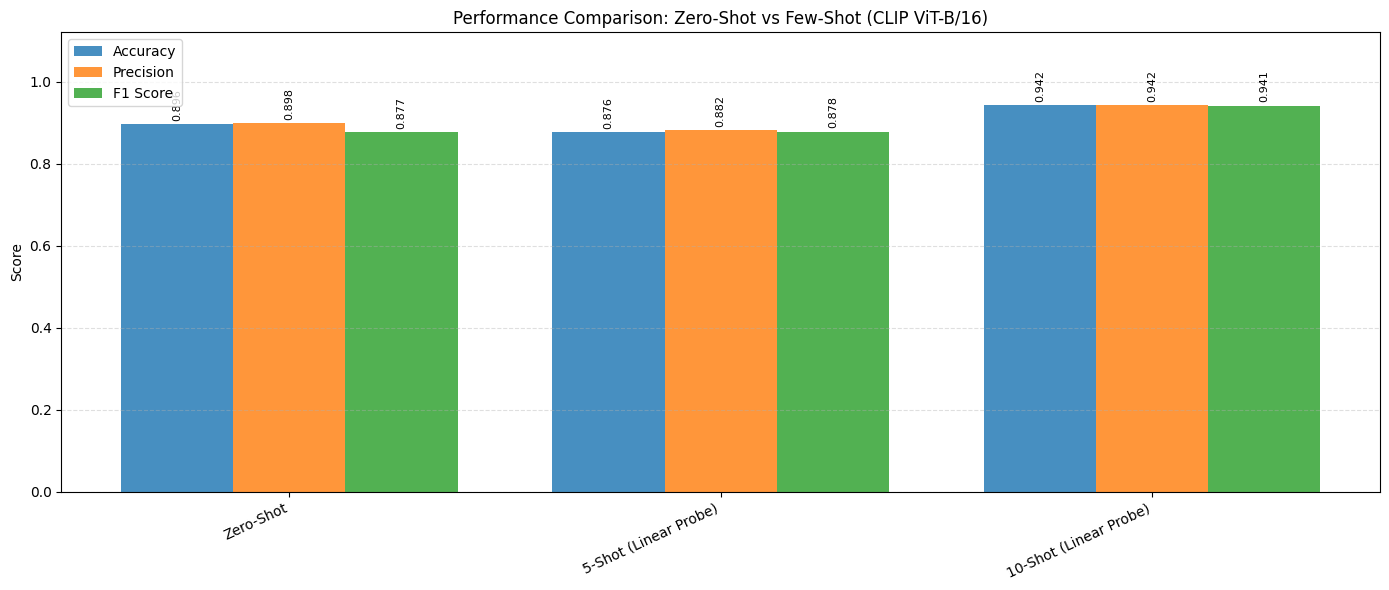

In [20]:
methods   = summary_df["Method"].tolist()
accs      = summary_df["Accuracy"].tolist()
precs     = summary_df["Precision"].tolist()
f1s       = summary_df["F1"].tolist()

x     = np.arange(len(methods))
width = 0.26

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width, accs, width, label="Accuracy",  alpha=0.82)
b2 = ax.bar(x,          precs, width, label="Precision", alpha=0.82)
b3 = ax.bar(x + width, f1s,  width, label="F1 Score",  alpha=0.82)

for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.008,
            f"{h:.3f}", ha="center", va="bottom", fontsize=8, rotation=90
        )

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=25, ha="right")
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Performance Comparison: Zero-Shot vs Few-Shot (CLIP ViT-B/16)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
save_fig("metrics_grouped_bar.png")
plt.show()
plt.close()

### 8.3  Accuracy-only bar chart

  Saved: results_output/accuracy_bar.png


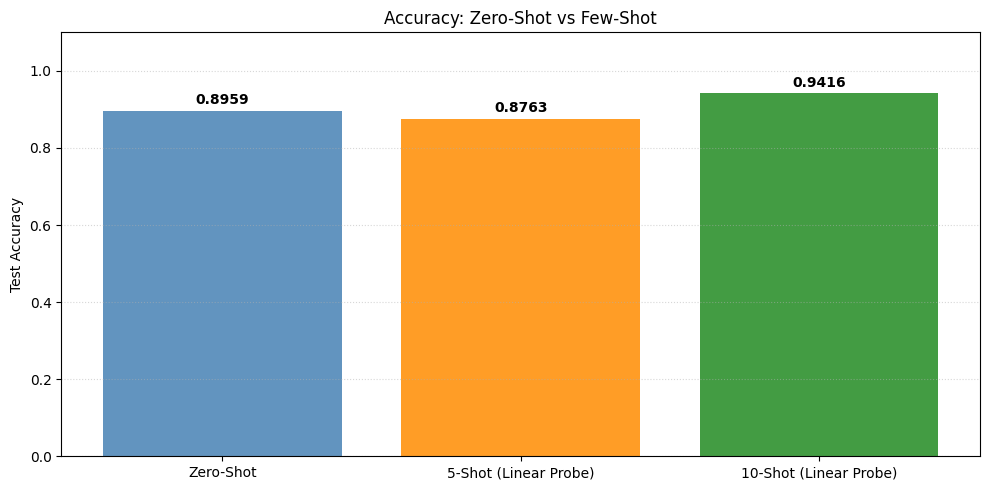

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, accs, color=["steelblue", "darkorange", "forestgreen"], alpha=0.85)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.4f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Test Accuracy")
ax.set_title("Accuracy: Zero-Shot vs Few-Shot")
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
save_fig("accuracy_bar.png")
plt.show()
plt.close()

### 8.4  Training curves (loss and validation accuracy)

  Saved: results_output/training_curves.png


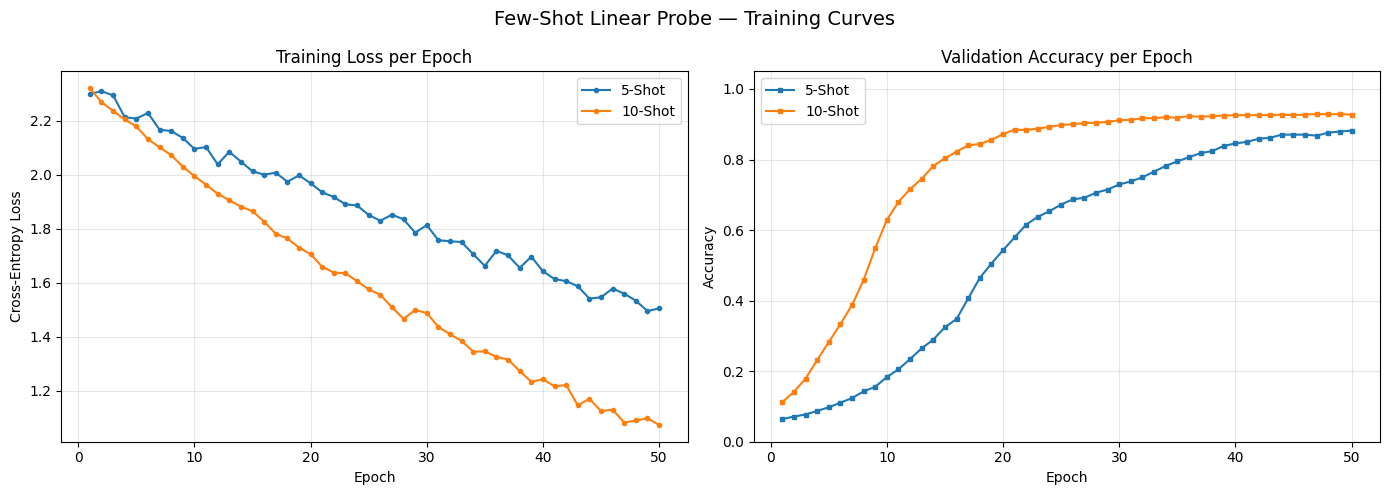

In [22]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))

colours = {5: "tab:blue", 10: "tab:orange"}

for K, exp in experiment_results.items():
    epochs = range(1, len(exp["train_losses"]) + 1)
    ax_loss.plot(epochs, exp["train_losses"], marker="o", markersize=3,
                 label=f"{K}-Shot", color=colours[K])
    ax_acc.plot(epochs, exp["val_accs"],     marker="s", markersize=3,
                label=f"{K}-Shot", color=colours[K])

ax_loss.set_title("Training Loss per Epoch")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Cross-Entropy Loss")
ax_loss.legend()
ax_loss.grid(alpha=0.3)

ax_acc.set_title("Validation Accuracy per Epoch")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.set_ylim(0, 1.05)
ax_acc.legend()
ax_acc.grid(alpha=0.3)

plt.suptitle("Few-Shot Linear Probe — Training Curves", fontsize=14)
plt.tight_layout()
save_fig("training_curves.png")
plt.show()
plt.close()

### 8.5  Confusion matrices

  Saved: results_output/confusion_matrices.png


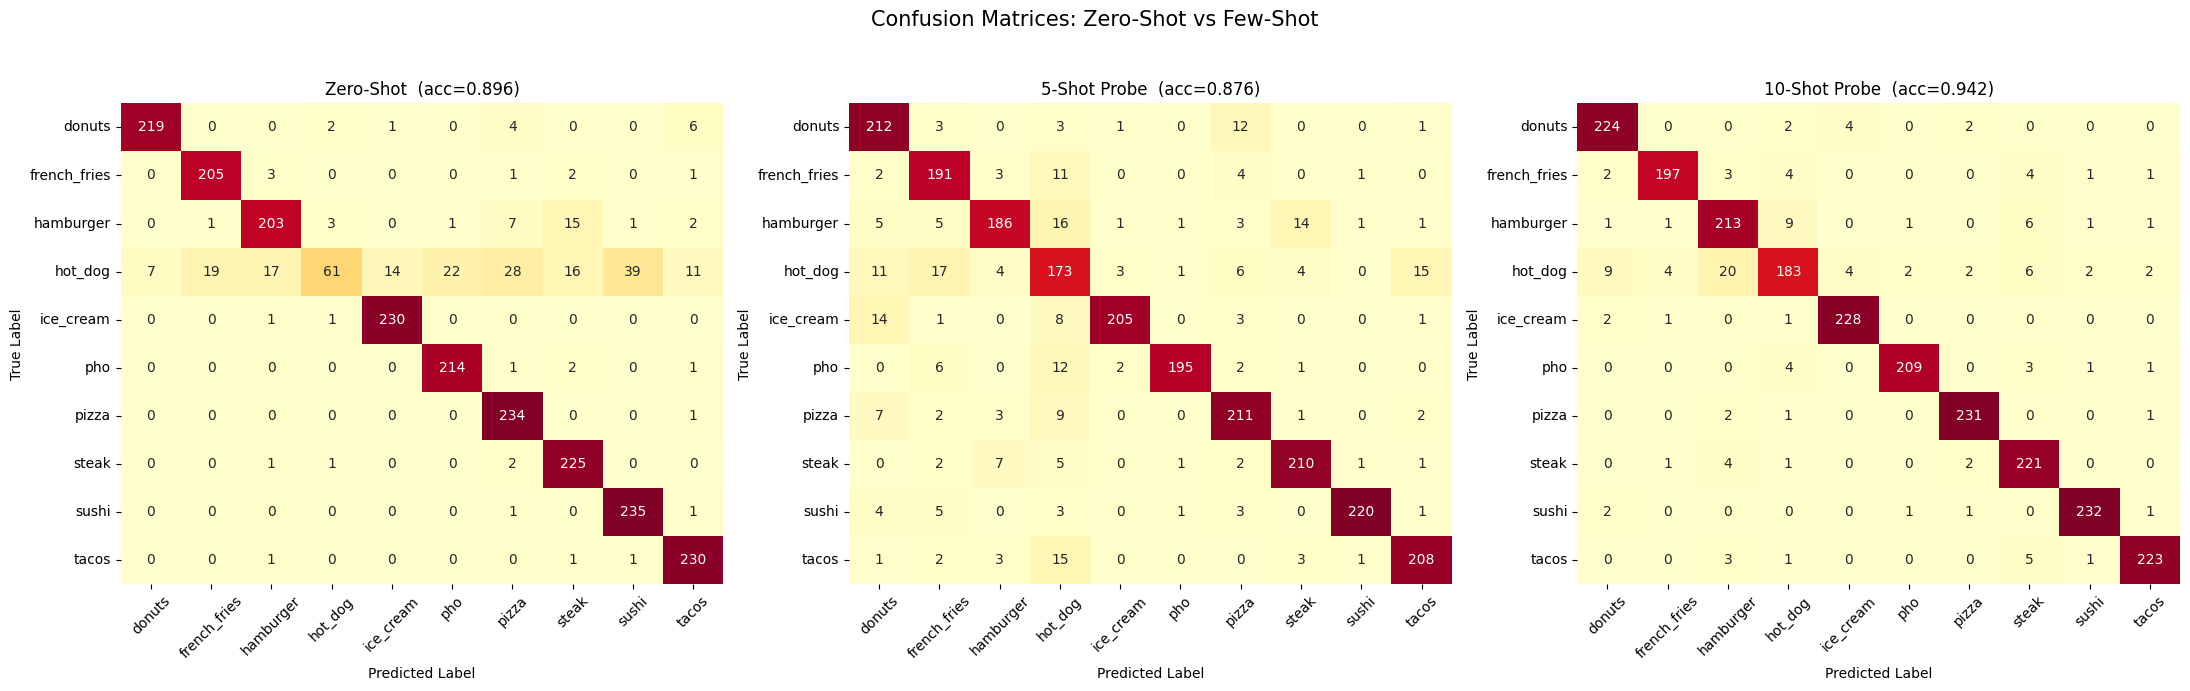

In [23]:
panels = [
    ("Zero-Shot",  zs_labels,                        zs_preds),
    ("5-Shot Probe",  experiment_results[5]["test_labs"],  experiment_results[5]["test_preds"]),
    ("10-Shot Probe", experiment_results[10]["test_labs"], experiment_results[10]["test_preds"]),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (title, y_true, y_pred) in zip(axes, panels):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        ax=ax,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        xticklabels=category_names,
        yticklabels=category_names,
        cbar=False,
    )
    acc_val = accuracy_score(y_true, y_pred)
    ax.set_title(f"{title}  (acc={acc_val:.3f})", fontsize=12)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Confusion Matrices: Zero-Shot vs Few-Shot", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_fig("confusion_matrices.png")
plt.show()
plt.close()

### 8.6  Calibration: Expected Calibration Error (ECE) and Reliability Diagrams

In [24]:
def get_confidence_scores(
    model: LinearProbe,
    loader: DataLoader,
    device: str = "cuda",
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute softmax-based confidence for each test sample."""
    model.eval()
    preds_out, labs_out, confs_out = [], [], []

    with torch.no_grad():
        for imgs, txts, labs in loader:
            imgs  = imgs.to(device)
            probs = torch.softmax(model(imgs, txts), dim=1)
            conf, pred = probs.max(dim=1)
            preds_out.extend(pred.cpu().numpy())
            labs_out.extend(labs.numpy())
            confs_out.extend(conf.cpu().numpy())

    return np.array(preds_out), np.array(labs_out), np.array(confs_out)


def expected_calibration_error(
    confs: np.ndarray,
    preds: np.ndarray,
    labels: np.ndarray,
    n_bins: int = 15,
):
    """Compute ECE and per-bin statistics."""
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    bin_accs, bin_confs, bin_counts = [], [], []

    for lo, hi, last in zip(bin_edges[:-1], bin_edges[1:],
                            [False] * (n_bins - 1) + [True]):
        mask = (confs >= lo) & (confs <= hi) if last else (confs >= lo) & (confs < hi)
        if mask.any():
            bin_acc  = (preds[mask] == labels[mask]).mean()
            bin_conf = confs[mask].mean()
            bin_cnt  = int(mask.sum())
        else:
            bin_acc = bin_conf = 0.0
            bin_cnt = 0
        ece += (bin_cnt / len(confs)) * abs(bin_acc - bin_conf)
        bin_accs.append(bin_acc)
        bin_confs.append(bin_conf)
        bin_counts.append(bin_cnt)

    return float(ece), np.array(bin_accs), np.array(bin_confs), bin_edges


# Collect calibration data
calib_entries = [
    {"label": "Zero-Shot",    "preds": zs_preds,  "labs": zs_labels, "confs": zs_confs},
]
for K in [5, 10]:
    exp = experiment_results[K]
    p, l, c = get_confidence_scores(exp["model"], loader_test, device=DEVICE)
    calib_entries.append({"label": f"{K}-Shot Probe", "preds": p, "labs": l, "confs": c})

# Compute ECE for each
for entry in calib_entries:
    ece, b_acc, b_conf, b_edges = expected_calibration_error(
        entry["confs"], entry["preds"], entry["labs"]
    )
    entry.update({"ece": ece, "bin_accs": b_acc, "bin_confs": b_conf, "bin_edges": b_edges})
    print(f"  {entry['label']:20s}  ECE={ece:.4f}")

  Zero-Shot             ECE=0.0284
  5-Shot Probe          ECE=0.7009
  10-Shot Probe         ECE=0.6615


  Saved: results_output/reliability_diagrams.png


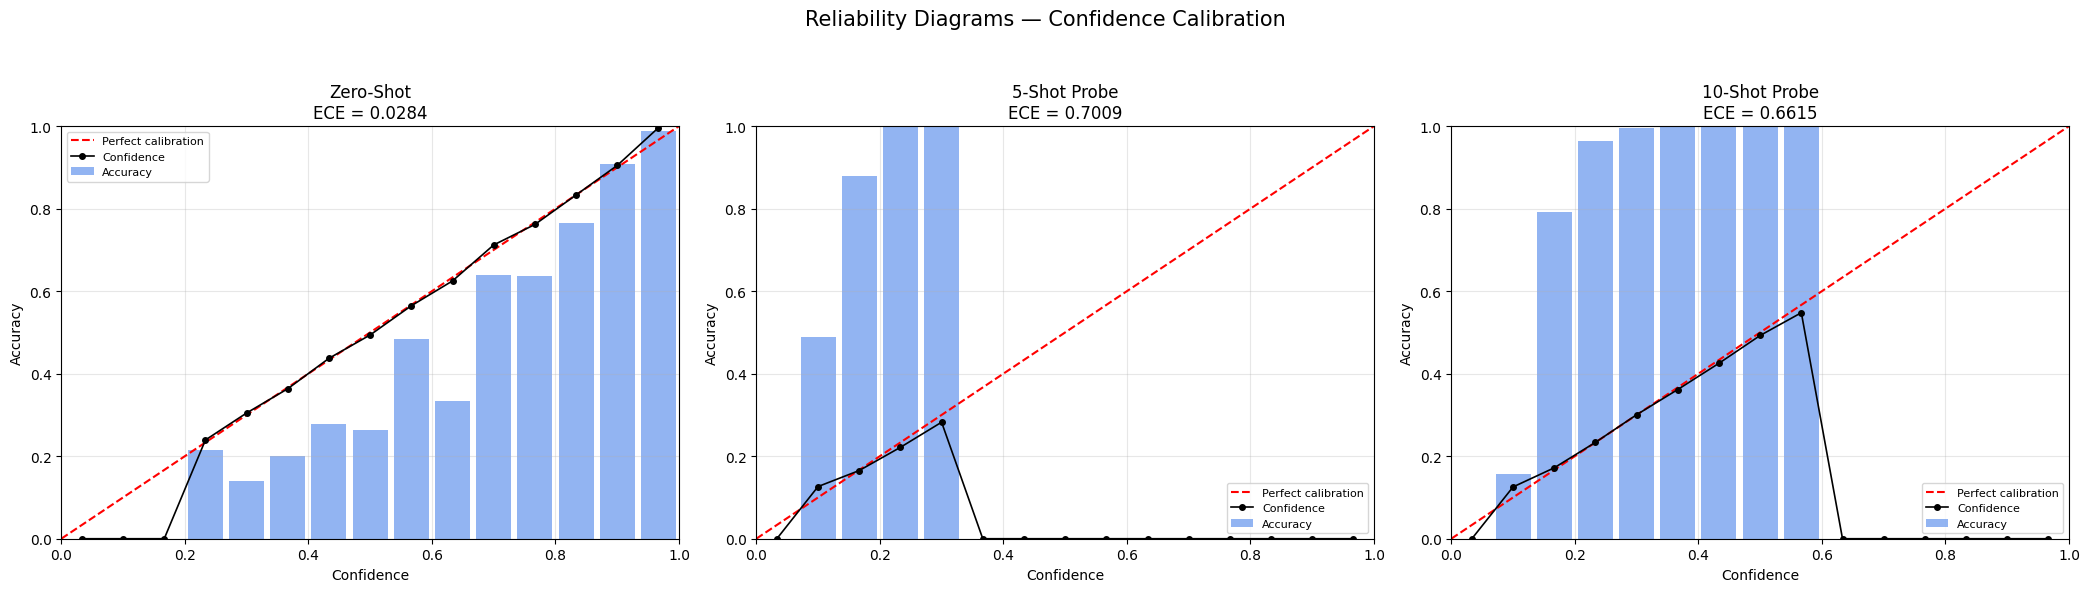

  Saved: results_output/calibration_ece_bar.png


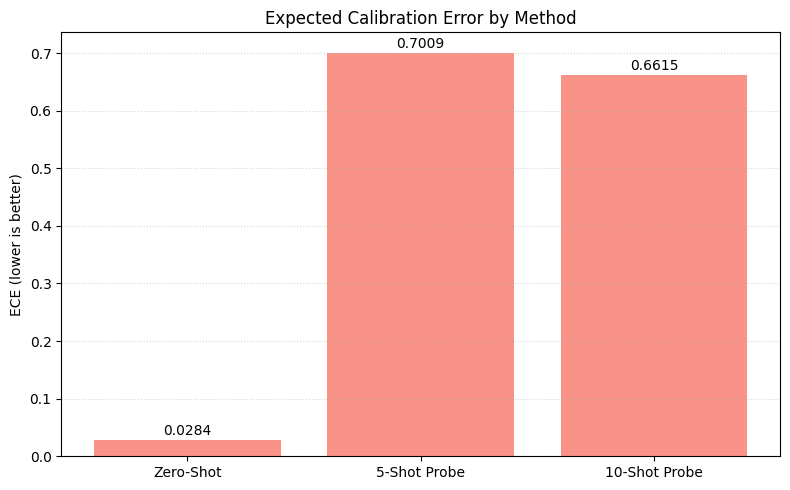

In [25]:
# Reliability diagrams
fig, axes = plt.subplots(1, len(calib_entries), figsize=(7 * len(calib_entries), 6))

for ax, entry in zip(axes, calib_entries):
    edges   = entry["bin_edges"]
    centres = (edges[:-1] + edges[1:]) / 2
    width   = (edges[1] - edges[0]) * 0.85

    ax.bar(centres, entry["bin_accs"], width=width, alpha=0.7, label="Accuracy", color="cornflowerblue")
    ax.plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect calibration")
    ax.plot(centres, entry["bin_confs"], "k-o", markersize=4, linewidth=1.2, label="Confidence")
    ax.set_title(f"{entry['label']}\nECE = {entry['ece']:.4f}", fontsize=12)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Reliability Diagrams — Confidence Calibration", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.94])
save_fig("reliability_diagrams.png")
plt.show()
plt.close()

# ECE bar chart
ece_labels = [e["label"] for e in calib_entries]
ece_values = [e["ece"]   for e in calib_entries]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(ece_labels, ece_values, alpha=0.85, color="salmon")
for i, v in enumerate(ece_values):
    ax.text(i, v + 0.003, f"{v:.4f}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("ECE (lower is better)")
ax.set_title("Expected Calibration Error by Method")
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
save_fig("calibration_ece_bar.png")
plt.show()
plt.close()

## Section 9 — Export All Results

In [26]:
# ── Predictions CSV ────────────────────────────────────────────────────────
pd.DataFrame({"true": zs_labels, "pred": zs_preds}).to_csv(
    os.path.join(OUTPUT_DIR, "zeroshot_predictions.csv"), index=False
)

for K, exp in experiment_results.items():
    pd.DataFrame({"true": exp["test_labs"], "pred": exp["test_preds"]}).to_csv(
        os.path.join(OUTPUT_DIR, f"{K}shot_predictions.csv"), index=False
    )

# ── Confusion matrix CSVs ──────────────────────────────────────────────────
pd.DataFrame(
    confusion_matrix(zs_labels, zs_preds),
    index=category_names, columns=category_names
).to_csv(os.path.join(OUTPUT_DIR, "zeroshot_confusion_matrix.csv"))

for K, exp in experiment_results.items():
    pd.DataFrame(
        confusion_matrix(exp["test_labs"], exp["test_preds"]),
        index=category_names, columns=category_names
    ).to_csv(os.path.join(OUTPUT_DIR, f"{K}shot_confusion_matrix.csv"))

# ── Training log CSVs ─────────────────────────────────────────────────────
for K, exp in experiment_results.items():
    n_ep = len(exp["train_losses"])
    pd.DataFrame({
        "epoch":       range(1, n_ep + 1),
        "train_loss":  exp["train_losses"],
        "val_acc":     exp["val_accs"],
    }).to_csv(os.path.join(OUTPUT_DIR, f"{K}shot_training_log.csv"), index=False)

# ── Calibration CSV ───────────────────────────────────────────────────────
pd.DataFrame([{
    "Method": e["label"], "ECE": e["ece"]
} for e in calib_entries]).to_csv(
    os.path.join(OUTPUT_DIR, "calibration_ece.csv"), index=False
)

# ── Raw pickle ────────────────────────────────────────────────────────────
bundle = {
    "zeroshot": {"preds": zs_preds, "labels": zs_labels, "confs": zs_confs,
                 "accuracy": zs_accuracy, "f1": zs_f1},
    "fewshot":  {K: {k: v for k, v in exp.items() if k != "model"}
                 for K, exp in experiment_results.items()},
    "categories": category_names,
}
with open(os.path.join(OUTPUT_DIR, "results_bundle.pkl"), "wb") as fh:
    pickle.dump(bundle, fh)

# ── Zip everything ────────────────────────────────────────────────────────
ZIP_PATH = "results_output.zip"
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for fname in files:
            full = os.path.join(root, fname)
            zf.write(full, os.path.relpath(full))

print("\nAll outputs saved to:", OUTPUT_DIR)
print("ZIP archive:", ZIP_PATH)
print("\nFiles exported:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f}")


All outputs saved to: results_output
ZIP archive: results_output.zip

Files exported:
  10shot_confusion_matrix.csv
  10shot_predictions.csv
  10shot_training_log.csv
  5shot_confusion_matrix.csv
  5shot_predictions.csv
  5shot_training_log.csv
  accuracy_bar.png
  calibration_ece.csv
  calibration_ece_bar.png
  confusion_matrices.png
  metrics_grouped_bar.png
  reliability_diagrams.png
  results_bundle.pkl
  summary_metrics.csv
  training_curves.png
  zeroshot_confusion_matrix.csv
  zeroshot_predictions.csv
